# Skrót zakresu reimplementacji

Graf architektury

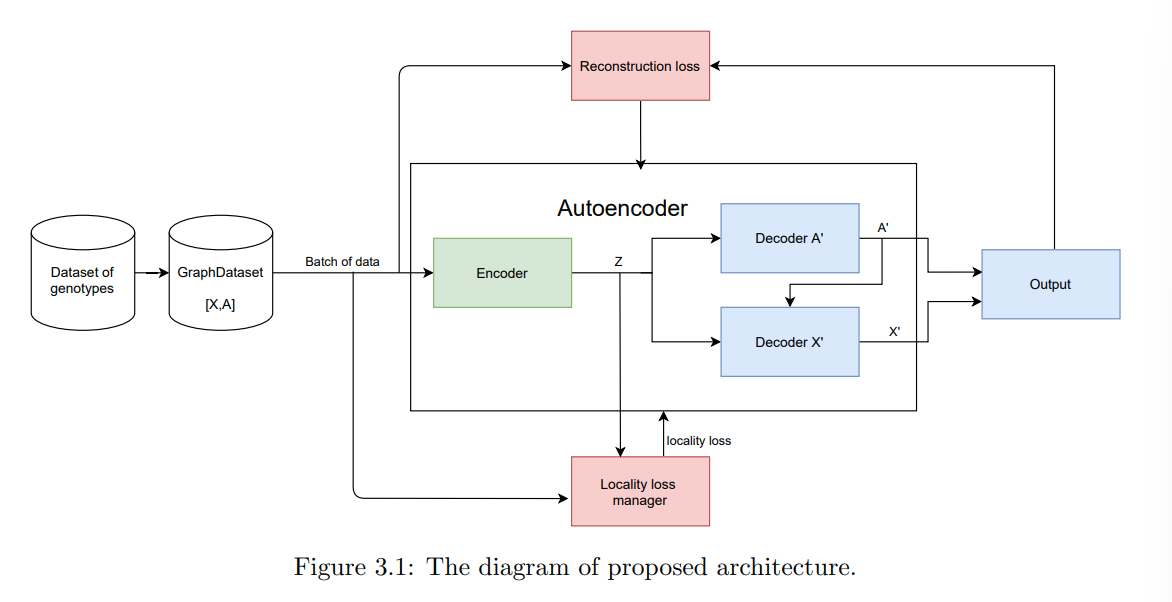

### Zbiór grafowy

Moduł odpowiedzialny za przetłumaczenie oryginalnego zbiory genotypów na zbiór grafów złożonych z X (feature matrix) oraz A (Adjacency matrix). Genotypy są zakodowane w f0, gdyż łatwo z takiej reprezentacji przetłumaczyć na X i A.

Translacja przebiega następująco:
1. Rozmiar A wynosi n x n, gdzie n to maksymalny liczba możliwych części
2. Rozmiar X wynosi n x f, gdzie f jest liczbą cech reprezentującą każdą część
3. Liczba części jest reprezentowana przez p, gdzie p <= n
4. p wierszy w X są wypełnione cechami, pozostałe są wypełnione przez -1
5. Aby zapewnić, że żadna cecha nie ma wartości -1, wszystkie wartości mniejsze niż 0 są przesuwane
6. Macierz A jest wypełniona 0 lub 1, gdzie 1 jest w miejscu odpowiadającym połączeniu części, pozostałe n - p wierzy jest wypełniona 0
<span style="color:yellow">Uwagi: czy zastosowanie w X wypełnień w postaci -1 jest odpowiednie? Czy przesunięcia są pożądane? Wprowadzić maskę 1 x n?</span>

Dwa możliwe podejścia do neuronów:
1. Traktowanie neuronów jako części. n zostaje rozszerzone o liczbę neuronów, a f o liczbę cech koniecznych do opisania neuronów. Wtedy cechy części powinny mieć nieistniejące wartości cech neuronowych, a neurony nieistniejące wartości dla cech części.
2. Złączenie neuronów z częścią. Wtedy f rozszerza się o liczbę cech wymaganą do opisu neuronu. Wprowadza to ograniczenie, że neuron jest związany z częścią
<span style="color:yellow">Uwagi: Jak powiązać neurony z częściami, zakodować, że neuron łączy np. dwie części. Zastosowanie kolejnej macierzy sąsiedztwa, incydencji B?</span>

###  Autoenkoder

Autoenkoder składa się z enkodera i dwóch dekoderów.
Cztery możliwe wybory grafowych warstw:
- GCSconv
- GCNconv
- ARMAconv
- GATconv
Przygotowano dwa podejścia:
1. GAE - klasyczne podejście z autoenkoderem z wykorzystaniem GNN
2. VGAE - wersja wariacyjna autoenodera

### Enkoder GAE

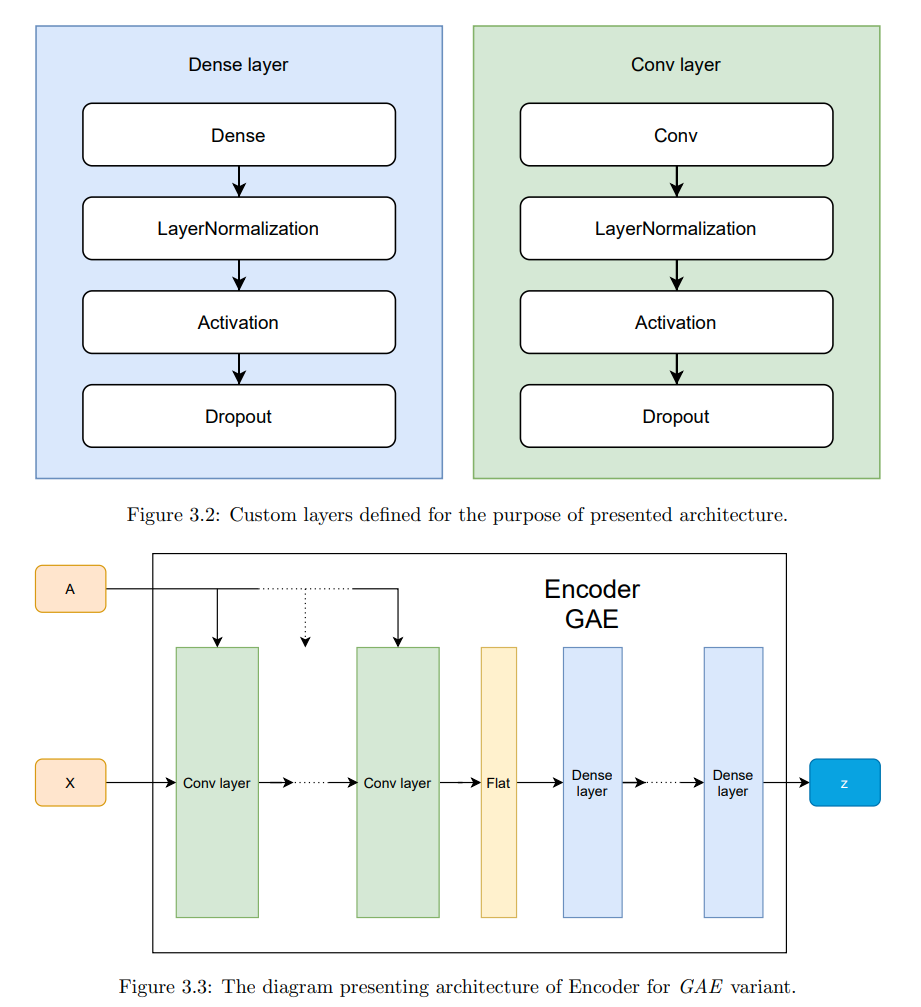

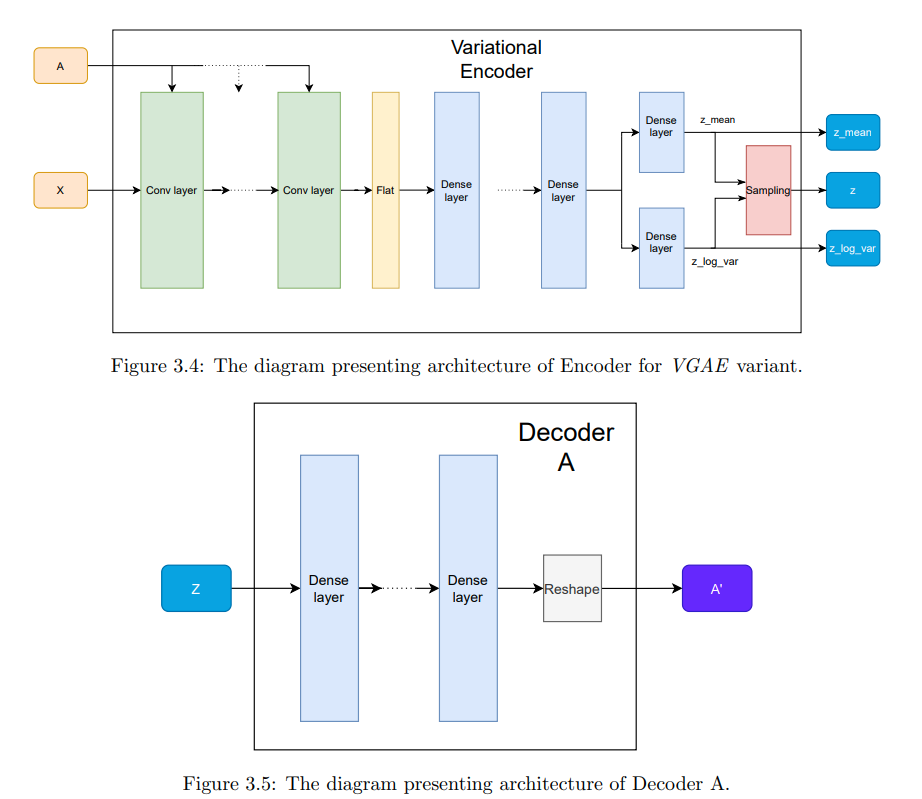

Dekoder A' składa się wyłącznie z warstw gęstych od 1 do 5. Aktywacja sigmoidalna pod koniec. Zaokrąglanie do 0 1 w post processingu.

Dekoder X' używa do rekonstrukcji A'. Zawiera warstwy konwolucyjne i gęste tak jak enkoder. Przepływ przez dekoder wygląda następująco:
1. z przechodzi przez warstwę gęstą w celu otrzymania tensora latent_size x n
2. następne 1 lub 2 warstwy konwolucyjne przetwarzają wejście połączone z A'
3. Wypłaszczenie wyjścia warstw konwolucyjnych
4. Od 1 do 7 warstw gęstych, ostatnie warstwa ma rozmiar n * f
5. Zamiania wymiarowości do macierzy X' o rozmiarze n x f i odjęcie 1 bo ReLU nie może wygenerować -1, która jest wymagana
<span style="color:yellow">Uwagi: Czy dekoder nie powinien przypominać lustrzanego odbicia enkodera?</span>

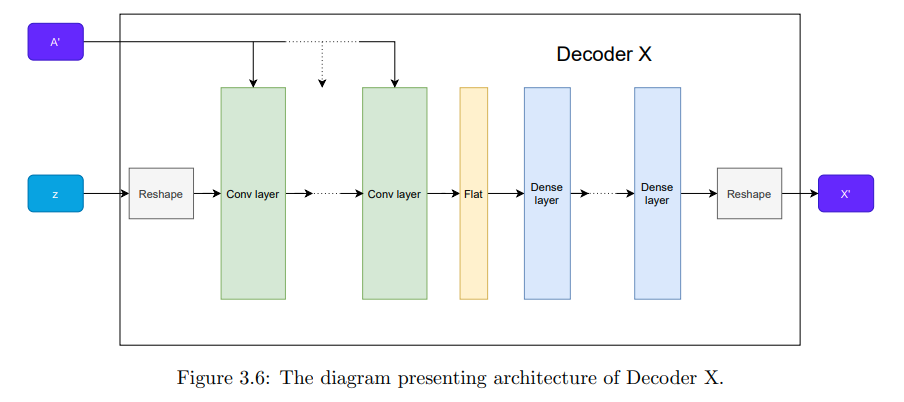

### Reconstruction loss

reconstruction_loss = MSE(A,A') * w + MSE(X,X').
'w' określa ważność straty w rekonstrukcji dla A (użyto w = 1000)
Wersja wariacyjna zawiera dodatkowo człon z dywergencją Kullbacka-Leiblera.
<span style="color:yellow">Uwagi: Inne funkcje straty. Czy MSE(A,A') to nie jest suma pomyłek podzielona przez n^2? </span>

# Imports